# Demos


## Manifold analysis example

Example of manifold analysis in Figure 5d,e and
Supplementary figure 5e-h.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Here we load the PC linear model data (Supplementary figure 3c,d)
mf_data = pd.read_excel('../data/SupplementaryFigure3.xlsx',
                       sheet_name='Figure S3b,c,d,f',
                       usecols='A:HY',
                       skiprows=2,
                       nrows=502)

pc_data = pd.read_excel('../data/SupplementaryFigure3.xlsx',
                       sheet_name='Figure S3b,c,d,f',
                       usecols='HZ:TP',
                       skiprows=2,
                       nrows=502)



In [3]:
import cbmanifold
from cbmanifold.linear_model import LinearModel

def source_data_to_LinearModel(data, label):
    _, n = data.shape
    n = (n - 1) // 2

    scale = 1e3  # kHz -> Hz

    rate = data.iloc[:, 0:n].values.T * scale
    drate = data.iloc[:, n : 2 * n].values.T * scale
    v0 = data.iloc[:, 2 * n].unique()[0]
    n_params = 1
    lm = LinearModel(
        rate=rate,
        drate=drate,
        label=label,
        params0 = [v0]
    )
    lm.n_params = n_params


    return lm


lm_mf = source_data_to_LinearModel(mf_data, "mossy fiber")
lm_pc = source_data_to_LinearModel(pc_data, "Purkinje cell")

figsize: [6. 5.]


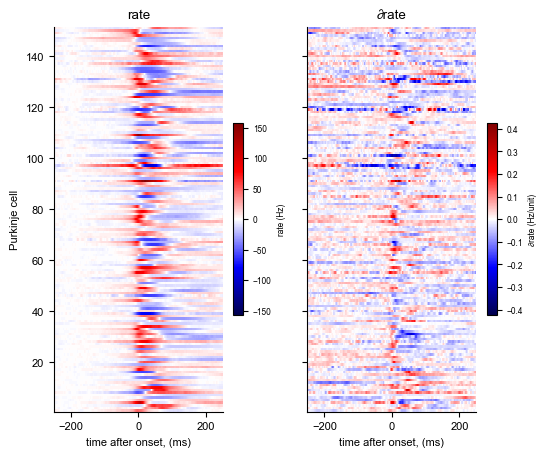

In [4]:
_, _ = cbmanifold.plot.plot_linear_model(lm_pc)

Dimensions: 1, Variance explained: 51.04384881006197
Dimensions: 2, Variance explained: 76.07985014983356
Dimensions: 3, Variance explained: 85.97231371969616
Dimensions: 4, Variance explained: 92.25990202100004
Dimensions: 5, Variance explained: 94.64670779103892
Dimensions to be reduced: 4


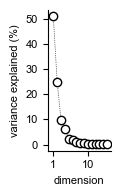

In [5]:
from cbmanifold.decomposition import pmPCA

dd, p, v = pmPCA(lm_pc.rate)
var_explained = dd/np.sum(dd)*1e2;
var_explained_cumsum = np.cumsum(var_explained);
for i in range(5):
    print(f'Dimensions: {i+1}, Variance explained: {var_explained_cumsum[i]}')

nmode = np.where(var_explained_cumsum > 87.5)[0][0]+1
print(f'Dimensions to be reduced: {nmode}')

_ = cbmanifold.plot.plot_var_explained(var_explained)


In [44]:
lmr = cbmanifold.decomposition.reduce_dimensionality(lm_pc, 4)
lmr = cbmanifold.utils.flip_sign(lmr, [1]) # flip signs to make the cycles go CCW

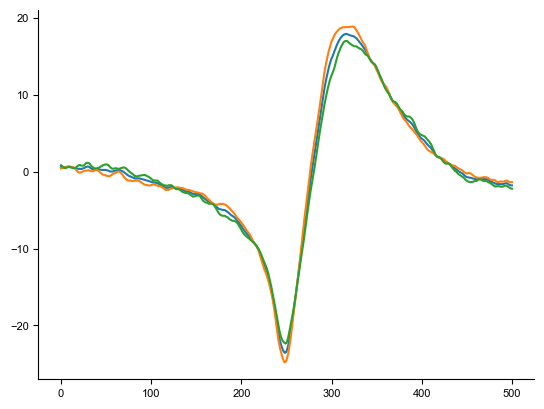

In [45]:
i = 1
plt.plot(0*lmr.dp[i,:]+lmr.p[i,:])
plt.plot(70*lmr.dp[i,:]+lmr.p[i,:])
plt.plot(-70*lmr.dp[i,:]+lmr.p[i,:])


(-30.0, 30.0)

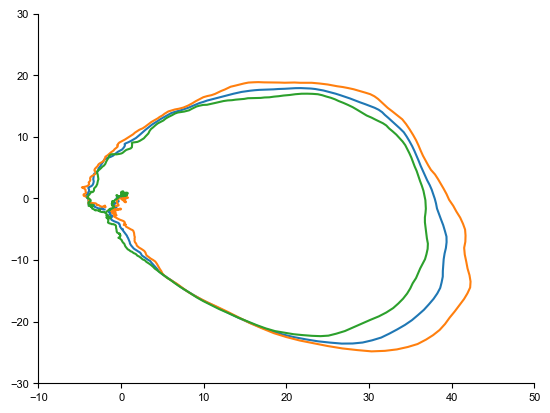

In [46]:
i1, i2 = 0, 1
plt.plot(0*lmr.dp[i1,:]+lmr.p[i1,:], 0*lmr.dp[i2,:]+lmr.p[i2,:])
plt.plot(70*lmr.dp[i1,:]+lmr.p[i1,:], 70*lmr.dp[i2,:]+lmr.p[i2,:])
plt.plot(-70*lmr.dp[i1,:]+lmr.p[i1,:], -70*lmr.dp[i2,:]+lmr.p[i2,:])
plt.xlim([-10, 50])
plt.ylim([-30, 30])


In [9]:
lmr

LinearModel(label='Purkinje cell', rate=array([[-0.37561891, -0.29563845, -0.23179841, ...,  0.6380616 ,
         0.75234   ,  0.8383616 ],
       [ 1.22964624,  1.24102209,  1.21261757, ..., -3.90484741,
        -3.87467699, -3.73667259],
       [ 1.84681647,  1.81633593,  1.7422342 , ..., -5.54854167,
        -5.57361504, -5.4394008 ],
       ...,
       [-1.65574828, -1.61072665, -1.53259539, ...,  4.85687988,
         4.905543  ,  4.81239106],
       [-1.2343765 , -1.19706335, -1.13633762, ...,  3.59593027,
         3.63775688,  3.57406935],
       [ 1.33741732,  1.32616701,  1.27965829, ..., -4.09005476,
        -4.09219685, -3.9783796 ]], shape=(151, 501)), drate=None, params0=[np.float64(591.3913)], is_dim_reduced=True)

## Linear model construction

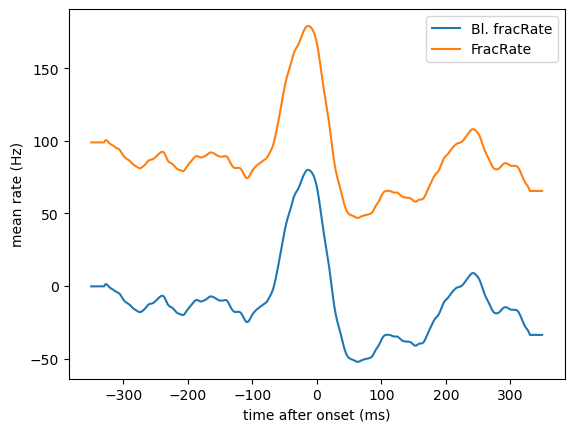

In [2]:
import scipy.io as io
import numpy as np

# importing cbManifold in case section one did not run
import cbmanifold
from cbmanifold.linear_model import LinearModel
from cbmanifold.utils.rate_estimator import get_rate_matrix

# importing matplotlib
import matplotlib.pyplot as plt

pc3_data = io.loadmat('../data/ike130709ch1s1e1_0.mat')

#time
t = pc3_data['t'].ravel()

# spikes
ss = pc3_data['ss']

# peak velocity
pv = pc3_data['v'].ravel() * 1000

# duration
dur = pc3_data['dur'].ravel()
av = 15./dur*1e3 # average velocity

# rate, fractionate rate
rate = cbmanifold.utils.filter_matrix(ss.T, sigma=15).T

# creating fracrate
from scipy.signal import get_window

def fracrate_matrix(spike_matrix, wsize=15, window_type="tukey"):
    """
    Computes firing rates from a binary spike matrix (trials x time).
    
    Parameters:
    - spike_matrix: np.ndarray of shape (n_trials, time)
    - wsize: int, window size for smoothing
    - window_type: str, type of window to use (e.g., "tukey", "hann")
    
    Returns:
    - rate_matrix: np.ndarray of same shape as spike_matrix
    """
    n_trials, L = spike_matrix.shape
    rate_matrix = np.zeros_like(spike_matrix, dtype=float)

    win = get_window(window_type, wsize)
    win /= win.sum()

    for i in range(n_trials):
        tspike = np.where(spike_matrix[i] == 1)[0]
        r = np.zeros(L)
        if len(tspike) >= 2:
            isi = np.diff(tspike) / 1e3  # convert to seconds
            for j in range(len(tspike) - 1):
                r[tspike[j]:tspike[j+1]] = 1 / isi[j]

        # Smooth the rate using the convolution
        rx = np.convolve(r, win, mode="valid")
        delta = L - rx.size
        d2 = delta // 2 + 1
        r[:d2] = rx[0]
        r[d2:d2+rx.size] = rx
        r[d2+rx.size:] = rx[-1]

        rate_matrix[i] = r

    return rate_matrix

fracRate = fracrate_matrix(ss, wsize = 40)

def baselining(rateMatrix, blTime):
    baselinedRate = np.zeros(shape = (rateMatrix.shape[0], rateMatrix.shape[1]))
    for row in range(rateMatrix.shape[0]):
        bl = np.mean(rateMatrix[row, :blTime])
        baselinedRate[row, :] = rateMatrix[row, :] - bl
    
    return baselinedRate

baselinedGaussian = baselining(rate, 25)
baselinedFracRate = baselining(fracRate, 25)


_, ax = plt.subplots()
#ax.plot(t, ss.mean(axis=0), label='spike')
ax.plot(t, baselinedFracRate.mean(axis=0), label='Bl. fracRate')
ax.plot(t, fracRate.mean(axis=0), label='FracRate')
ax.set(xlabel='time after onset (ms)', ylabel='mean rate (Hz)')
ax.legend()

In [3]:
# grand average of pv and av, from Markanday et al. 2023
pv0 = 591.3913
av0 = 352.6262

# single parameter model
params = np.vstack([pv]).T # should be n_trials x 1
lm = cbmanifold.linear_model.generate_linear_model('pc3', baselinedFracRate, params, [pv0],output_type="LinearModel")

[Text(0.5, 0, 'Time after onset (ms)'), Text(0, 0.5, 'rate (Hz)')]

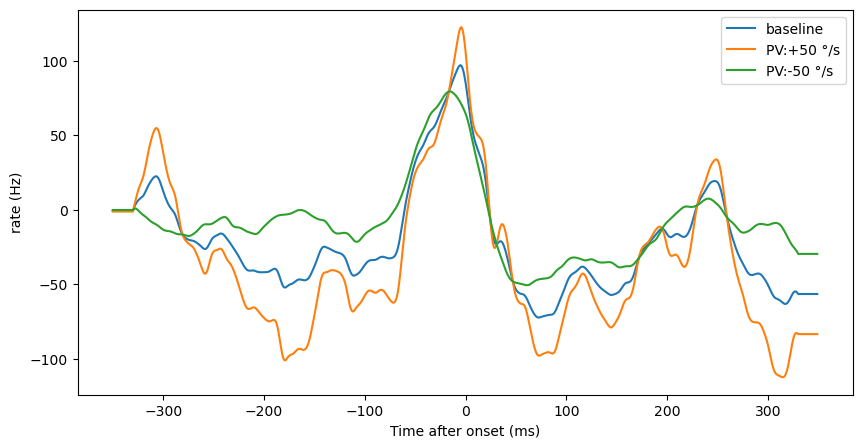

In [4]:
_, ax = plt.subplots(figsize = (10, 5))

# Plot baseline (kinematics-independent rate)
ax.plot(t, lm.rate, label='baseline')

# Plot +50 °/s change
params_high = lm.params0.copy()
params_high[0] += 100  # increase peak velocity by 50
rate_high = lm.predict(params_high)
ax.plot(t, rate_high, label='PV:+50 °/s')

# Plot -50 °/s change
params_low = lm.params0.copy()
params_low[0] -= 100  # decrease peak velocity by 50
rate_low = lm.predict(params_low)
ax.plot(t, rate_low, label='PV:-50 °/s')

ax.legend()
ax.set(xlabel='Time after onset (ms)', ylabel='rate (Hz)')

In [5]:
# two parameter model --- Now generate the model in a dict type
dur0 = 57
params = np.vstack([pv, dur]).T  # should be n_trials x 2
lmD = cbmanifold.linear_model.generate_linear_model('pc3',
    baselinedFracRate, params, [pv0, dur0], output_type="dict"
)

Text(0.0, -0.5, 'Peak firing rate seems equaly dependent on both PV and duration.')

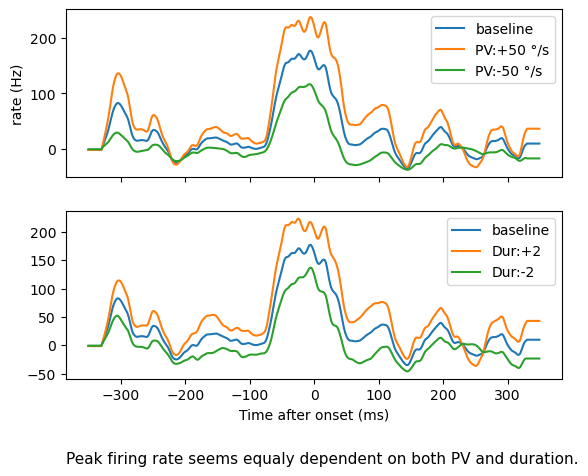

In [28]:
# a dictionary type model can be converted to a LinearModel type.
lmc = cbmanifold.linear_model.LinearModel.from_dict(lmD)

_, ax = plt.subplots(nrows=2, sharex=True)

# Top panel - Peak Velocity changes
ax[0].plot(t, lmc.rate, label="baseline")

# PV +50
params_high_pv = lmc.params0.copy()
params_high_pv[0] += 50  # increase peak velocity by 50
rate_high_pv = lmc.predict(params_high_pv)
ax[0].plot(t, rate_high_pv, label="PV:+50 °/s")

# PV -50
params_low_pv = lmc.params0.copy()
params_low_pv[0] -= 50  # decrease peak velocity by 50
rate_low_pv = lmc.predict(params_low_pv)
ax[0].plot(t, rate_low_pv, label="PV:-50 °/s")

ax[0].legend()
ax[0].set_ylabel("rate (Hz)")

# Bottom panel - Average Velocity changes
ax[1].plot(t, lmc.rate, label="baseline")

# AV +50
params_high_av = lmc.params0.copy()
params_high_av[1] += 2  # increase average velocity by 50
rate_high_av = lmc.predict(params_high_av)
ax[1].plot(t, rate_high_av, label="Dur:+2")

# AV -50
params_low_av = lmc.params0.copy()
params_low_av[1] -= 2 # decrease average velocity by 50
rate_low_av = lmc.predict(params_low_av)
ax[1].plot(t, rate_low_av, label="Dur:-2")

ax[1].legend()
ax[1].set_xlabel("Time after onset (ms)")

# Add explanatory text
ax[1].text(0.0, -0.5,
    """Peak firing rate seems equaly dependent on both PV and duration.""",
    transform=ax[1].transAxes,
    wrap=True,
    size=11
)

In [17]:
params

array([[570.85510468,  53.        ],
       [526.71806538,  58.        ],
       [491.65931836,  57.        ],
       [500.45643812,  58.        ],
       [548.38852007,  55.        ],
       [515.14122953,  58.        ],
       [509.14379169,  56.        ],
       [517.82672262,  59.        ],
       [583.86681698,  53.        ],
       [459.68998326,  58.        ],
       [451.84698906,  62.        ],
       [465.07777094,  59.        ],
       [430.08354662,  60.        ],
       [492.85753982,  56.        ],
       [532.565059  ,  55.        ]])

Text(0, 0.5, 'Dur')

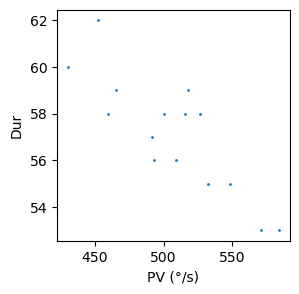

In [29]:
_, ax = plt.subplots(figsize=(3, 3))

ax.scatter(params[:,0], params[:,1], 1)
ax.set_xlabel('PV (°/s)')
ax.set_ylabel('Dur')


In [25]:
# creating a pandas dataframe
data = pd.DataFrame({
        "label": np.repeat(lmc.label, lmc.rate.shape[0]),
        "rate": lmc.rate,
        "drate1": lmc.drate[0, :],
        "drate2": lmc.drate[1, :],
        })

In [26]:
data

,label,rate,drate1,drate2
0,pc3,-1.274746,-0.012794,-0.158563
1,pc3,-1.274746,-0.012794,-0.158563
2,pc3,-1.274746,-0.012794,-0.158563
3,pc3,-1.274746,-0.012794,-0.158563
4,pc3,-1.274746,-0.012794,-0.158563
...,...,...,...,...
695,pc3,9.662386,0.535496,16.594730
696,pc3,9.662386,0.535496,16.594730
697,pc3,9.662386,0.535496,16.594730
698,pc3,9.662386,0.535496,16.594730


## Linear model construction - old way

The code above is based on a revised version of the generation. The old way is still available.

In [54]:
# note that the old way received duration as a parameter
params_old = np.vstack([pv, dur]).T

lmol = cbmanifold.linear_model.generate_linear_model_old('pc3', rate, params_old, [pv0, av0], target_dist=15, output_type="dict")

lm = cbmanifold.linear_model.LinearModel.from_dict(lmol)

[Text(0.5, 0, 'Time after onset (ms)'), Text(0, 0.5, 'rate (Hz)')]

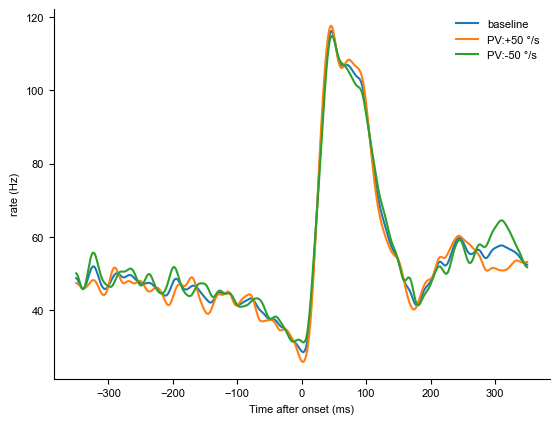

In [56]:
_, ax = plt.subplots()

# Plot baseline (original rate)
ax.plot(t, lm.rate, label='baseline')

# Plot +50 °/s change
params_high = lm.params0.copy()
params_high[0] += 50  # increase peak velocity by 50
rate_high = lm.predict(params_high)
ax.plot(t, rate_high, label='PV:+50 °/s')

# Plot -50 °/s change
params_low = lm.params0.copy()
params_low[0] -= 50  # decrease peak velocity by 50
rate_low = lm.predict(params_low)
ax.plot(t, rate_low, label='PV:-50 °/s')

ax.legend()
ax.set(xlabel='Time after onset (ms)', ylabel='rate (Hz)')

Text(0.5, 1.0, 'This is the same result as the new way')

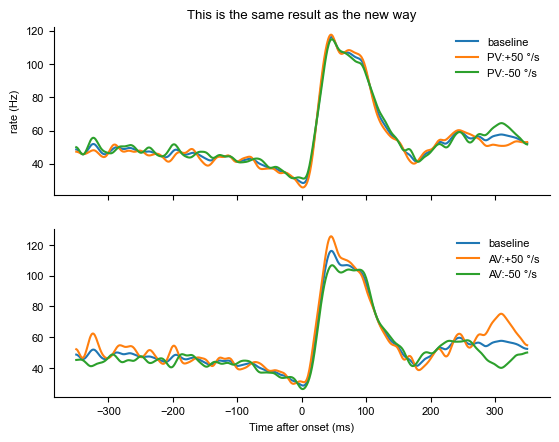

In [57]:
_, ax = plt.subplots(nrows=2, sharex=True)
ax[0].plot(t, lm.rate, label="baseline")
ax[0].plot(t, lm.rate + lm.wv * 50, label="PV:+50 °/s")
ax[0].plot(t, lm.rate - lm.wv * 50, label="PV:-50 °/s")
ax[0].legend()
ax[0].set_ylabel("rate (Hz)")

ax[1].plot(t, lm.rate, label="baseline")
ax[1].plot(t, lm.rate + lm.wr * 50, label="AV:+50 °/s")
ax[1].plot(t, lm.rate - lm.wr * 50, label="AV:-50 °/s")
ax[1].legend()
ax[1].set_xlabel("Time after onset (ms)")

ax[0].set_title(
    """This is the same result as the new way""")